# ARMA Baseline for ECG Anomaly Detection

This notebook runs the first complete anomaly detection experiment.

Pipeline:
1. load MIT-BIH records;
2. segment ECG beats using annotations;
3. split train/test by record;
4. fit an ARMA-based anomaly threshold on normal training beats;
5. evaluate predictions on test beats.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import config
from utils import (
    load_mit_bih_record,
    create_beat_dataset,
    split_by_record,
    evaluate_anomaly_detection,
)
from models import ARMAModel

## Load a Small Subset

ARMA is computationally expensive here because we fit a small model for each beat. For the first run, we use only a few records to validate the pipeline.

In [2]:
N_RECORDS = 5

records_file = Path(config.MIT_BIH_PATH) / "RECORDS"
record_names = records_file.read_text().splitlines()[:N_RECORDS]

records = []
for record_name in record_names:
    record = load_mit_bih_record(config.MIT_BIH_PATH, record_name)
    if record is not None:
        records.append(record)

print(f"Loaded {len(records)} records: {record_names}")

Loaded 5 records: ['100', '101', '102', '103', '104']


## Create Beat Dataset

Each row is one ECG beat window. The label belongs to the whole beat segment, not to a single sample.

In [3]:
dataset = create_beat_dataset(records, normalize=True)

print(dataset.shape)
display(dataset[["record", "sample", "symbol", "label", "label_name"]].head())
display(dataset["label_name"].value_counts())
display(dataset["symbol"].value_counts().head(10))

(10634, 7)

,record,sample,symbol,label,label_name
0,100,370,N,0,normal
1,100,662,N,0,normal
2,100,946,N,0,normal
3,100,1231,N,0,normal
4,100,1515,N,0,normal


label_name
normal     6440
anomaly    4194
Name: count, dtype: int64

symbol
N    6440
/    3407
f     722
A      38
Q      20
V       7
Name: count, dtype: int64

In [4]:
X = np.stack(dataset["signal"].values)
y = dataset["label"].values
metadata = dataset.drop(columns=["signal", "label"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10634, 180)
y shape: (10634,)


## Train/Test Split by Record

Splitting by record avoids putting beats from the same patient/record in both train and test.

In [5]:
split = split_by_record(X, y, metadata)

print("Train records:", split["train_records"])
print("Test records:", split["test_records"])
print("Train shape:", split["X_train"].shape)
print("Test shape:", split["X_test"].shape)

print("Train labels:")
display(pd.Series(split["y_train"]).value_counts().rename(index={0: "normal", 1: "anomaly"}))

print("Test labels:")
display(pd.Series(split["y_test"]).value_counts().rename(index={0: "normal", 1: "anomaly"}))

Train records: ['100', '101', '102', '103']
Test records: ['104']
Train shape: (8406, 180)
Test shape: (2228, 180)
Train labels:


normal     6277
anomaly    2129
Name: count, dtype: int64

Test labels:


anomaly    2065
normal      163
Name: count, dtype: int64

## Fit ARMA Threshold

The ARMA score is one Mean Squared Error value per beat. The threshold is estimated from normal training beats.

In [6]:
MAX_TRAIN_NORMAL = 150
MAX_TEST_PER_CLASS = 150
rng = np.random.default_rng(config.RANDOM_SEED)

X_train_normal = split["X_train"][split["y_train"] == 0]
X_train_normal = X_train_normal[:MAX_TRAIN_NORMAL]

test_indices = []
for label in [0, 1]:
    label_indices = np.where(split["y_test"] == label)[0]
    rng.shuffle(label_indices)
    test_indices.extend(label_indices[:MAX_TEST_PER_CLASS])

test_indices = np.array(test_indices)
rng.shuffle(test_indices)

X_test_small = split["X_test"][test_indices]
y_test_small = split["y_test"][test_indices]

arma = ARMAModel(p=1, d=0, q=1, threshold_percentile=95)
arma.fit(X_train_normal)

print("Training normal beats used:", len(X_train_normal))
print("Test beats used:", len(X_test_small))
display(pd.Series(y_test_small).value_counts().rename(index={0: "normal", 1: "anomaly"}))
print("Threshold:", arma.threshold)

Training normal beats used: 150
Test beats used: 300


normal     150
anomaly    150
Name: count, dtype: int64

Threshold: 0.0007765653322197417


## Evaluate

In [7]:
scores = arma.anomaly_score(X_test_small)
y_pred = arma.predict(X_test_small)

results = evaluate_anomaly_detection(y_test_small, y_pred, scores)
results

{'confusion_matrix': [[147, 3], [118, 32]],
 'precision': 0.9142857142857143,
 'recall': 0.21333333333333335,
 'f1': 0.34594594594594597,
 'roc_auc': 0.9554222222222222,
 'pr_auc': 0.9409122023916393}

### Metric Interpretation

With the default 95th percentile threshold, ARMA obtains high precision but low recall. This means that most beats flagged as anomalous are truly anomalous, but many true anomalies are still missed.

The ROC-AUC and PR-AUC are high, which suggests that the ARMA reconstruction error is informative as an anomaly score. However, converting this score into a binary decision depends strongly on the chosen threshold.

## Threshold Sensitivity

The threshold controls the trade-off between false positives and false negatives. In a medical screening context, a lower threshold may be preferable if missing an anomaly is considered more costly than triggering an additional check.

In [8]:
threshold_results = []
train_scores = arma.anomaly_score(X_train_normal)

for percentile in [95, 90, 85, 80, 75]:
    threshold = np.percentile(train_scores, percentile)
    y_pred_threshold = (scores > threshold).astype(int)
    metrics = evaluate_anomaly_detection(y_test_small, y_pred_threshold, scores)

    threshold_results.append({
        "percentile": percentile,
        "threshold": threshold,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "roc_auc": metrics["roc_auc"],
        "pr_auc": metrics["pr_auc"],
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

,percentile,threshold,precision,recall,f1,roc_auc,pr_auc
0,95,0.000777,0.914286,0.213333,0.345946,0.955422,0.940912
1,90,0.000765,0.914286,0.213333,0.345946,0.955422,0.940912
2,85,0.000752,0.918919,0.226667,0.363636,0.955422,0.940912
3,80,0.000745,0.921053,0.233333,0.372340,0.955422,0.940912
4,75,0.000733,0.928571,0.260000,0.406250,0.955422,0.940912


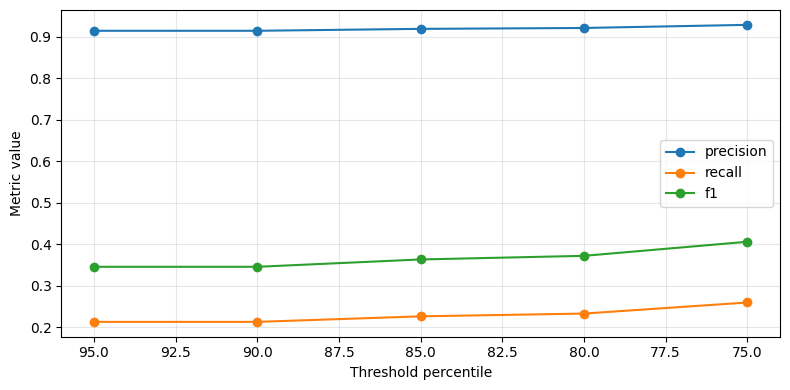

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["percentile"], threshold_df["precision"], marker="o", label="precision")
plt.plot(threshold_df["percentile"], threshold_df["recall"], marker="o", label="recall")
plt.plot(threshold_df["percentile"], threshold_df["f1"], marker="o", label="f1")
plt.gca().invert_xaxis()
plt.xlabel("Threshold percentile")
plt.ylabel("Metric value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Threshold Discussion

Lowering the threshold percentile makes the detector less conservative. In this experiment, recall and F1 improve when moving from the 95th percentile toward lower percentiles, while precision remains high.

This trade-off is important in a medical context: a false negative means missing a potentially abnormal beat, while a false positive may lead to further checks. For this reason, the threshold should not be treated as a fixed technical detail, but as a decision parameter related to the application goal.

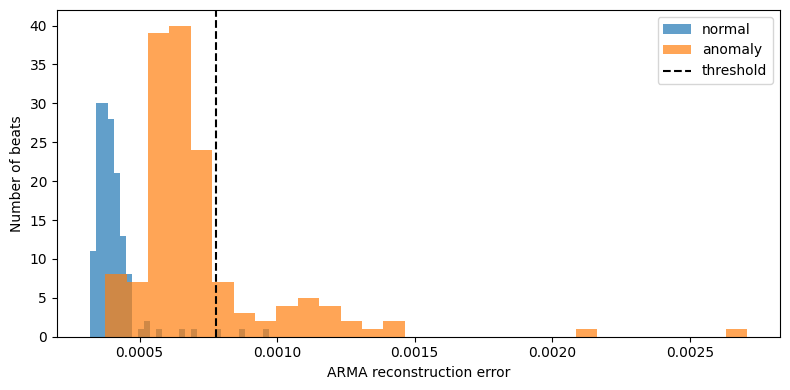

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(scores[y_test_small == 0], bins=30, alpha=0.7, label="normal")
plt.hist(scores[y_test_small == 1], bins=30, alpha=0.7, label="anomaly")
plt.axvline(arma.threshold, color="black", linestyle="--", label="threshold")
plt.xlabel("ARMA reconstruction error")
plt.ylabel("Number of beats")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation Notes

- ARMA is used as a classical time-series baseline.
- Each ECG beat is treated as a short time series.
- The anomaly score is the average squared reconstruction/prediction error.
- The threshold is learned from normal training beats and then applied to test beats.
- Precision and recall must be interpreted together: a high precision with low recall means that detected anomalies are reliable, but many true anomalies are missed.
- In a medical screening setting, a lower threshold may be preferred if false negatives are considered more costly than false positives.
- This model is mainly useful as a theoretical baseline; later models should handle ECG morphology more naturally.